# 🔮 Modélisation et Prédiction avec Prophet

Pour ce projet, le modèle **Prophet** (développé par l'équipe Data Science de Meta/Facebook) est de loin le plus intuitif et facile à expliquer.

Contrairement à ARIMA qui demande des mathématiques complexes (stationnarité, différenciation...), Prophet aborde le problème comme un simple ajustement de courbe. Il décompose directement notre prédiction en additionnant :
`Prédiction = Tendance + Saisonnalité Annuelle + Saisonnalité Hebdomadaire`

Exactement ce que nous avons observé dans le premier notebook !

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

plt.rcParams["figure.figsize"] = (12, 5)

Importing plotly failed. Interactive plots will not work.


## 1. Préparation des données pour Prophet

Prophet est très strict sur un point : il exige que notre DataFrame ait **exactement deux colonnes** avec des noms précis :
- `ds` : pour Date Stamp (les dates)
- `y` : pour la cible à prédire (nos Ventes)

In [2]:
# Chargement des données
df = pd.read_csv('../data/store_sales.csv')

# Renommer les colonnes pour satisfaire Prophet
df = df.rename(columns={'Date': 'ds', 'Sales': 'y'})
df['ds'] = pd.to_datetime(df['ds'])

display(df.head())

,ds,y
0,2020-01-01,497
1,2020-01-02,481
2,2020-01-03,508
3,2020-01-04,607
4,2020-01-05,557


## 2. Séparation Entraînement / Test

En séries temporelles, on ne peut pas mélanger les données au hasard ! Il faut respecter l'ordre chronologique.
Nous allons utiliser les données jusqu'à fin Septembre 2022 pour l'entraînement, et garder les **90 derniers jours (Oct-Déc 2022)** pour tester nos prédictions.

In [3]:
# On coupe le dataset 90 jours avant la fin
train_size = len(df) - 90
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Jours d'entraînement : {len(train)}")
print(f"Jours de test : {len(test)}")

Jours d'entraînement : 1006
Jours de test : 90


## 3. Création et Entraînement du Modèle

In [4]:
# Initialisation du modèle Prophet
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Entraînement sur nos données passées
model.fit(train)
print("Modèle entraîné avec succès !")

22:48:33 - cmdstanpy - INFO - Chain [1] start processing


22:48:35 - cmdstanpy - INFO - Chain [1] done processing


Modèle entraîné avec succès !


## 4. Prédictions sur le Futur

Nous demandons au modèle de générer un "calendrier du futur" de 90 jours, puis d'y inscrire ses prédictions.

In [5]:
# Création d'un dataframe contenant les dates futures (les 90 jours de notre test)
future_dates = model.make_future_dataframe(periods=90)

# Le modèle fait ses prédictions
forecast = model.predict(future_dates)

# 'yhat' est le nom de la colonne qui contient la prédiction de nos ventes
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
1091,2022-12-27,779.835465,743.674597,817.923605
1092,2022-12-28,782.956296,743.219431,821.472188
1093,2022-12-29,785.310232,749.484449,824.368409
1094,2022-12-30,782.804482,747.227931,819.578058
1095,2022-12-31,861.155876,821.229793,896.503641


## 5. Visualisation des Résultats et Évaluation

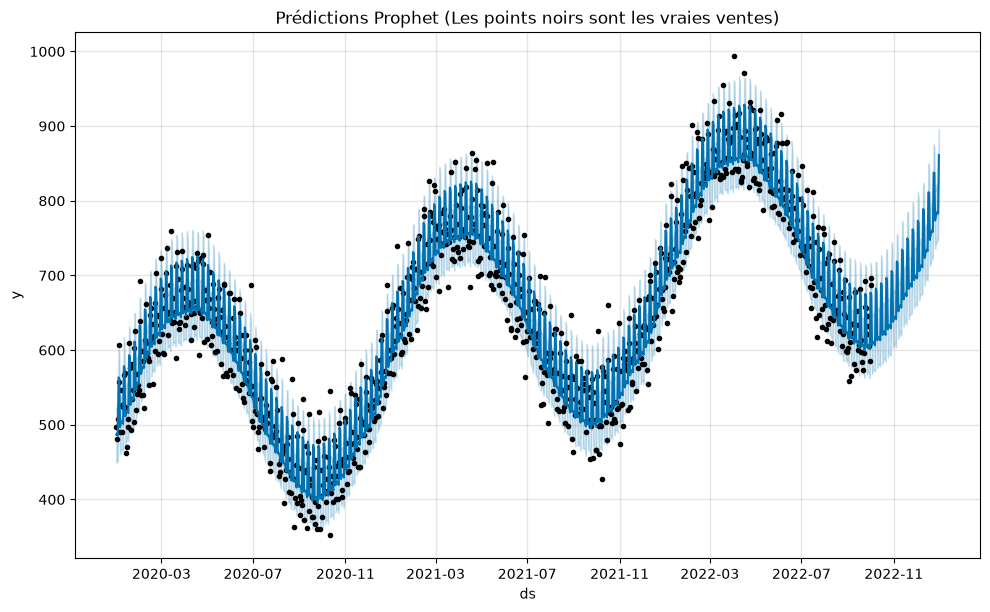

In [6]:
# Graphique principal de Prophet
fig1 = model.plot(forecast)
plt.title('Prédictions Prophet (Les points noirs sont les vraies ventes)')
plt.show()

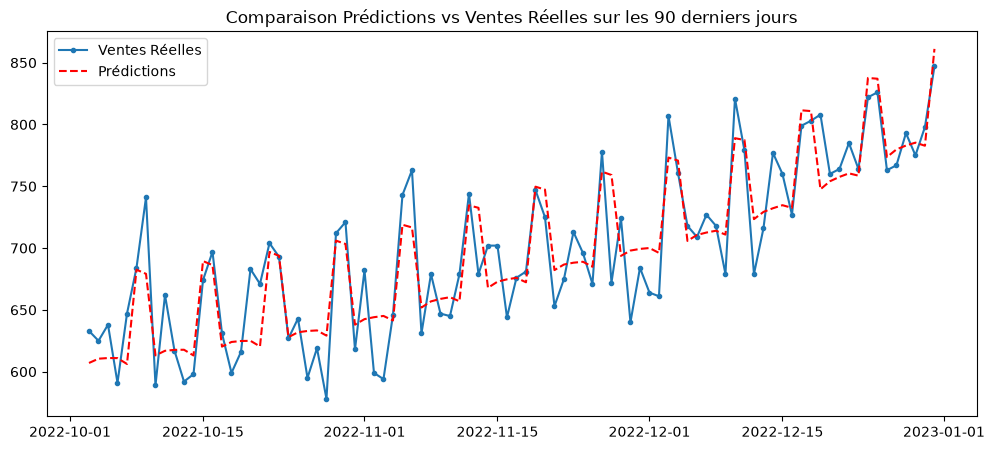

En moyenne, le modèle se trompe de 22 ventes par jour.


In [7]:
# Comparaison directe sur les 90 derniers jours (Test Set)
predictions_90_days = forecast.iloc[-90:]['yhat'].values
actual_90_days = test['y'].values

plt.figure(figsize=(12, 5))
plt.plot(test['ds'], actual_90_days, label='Ventes Réelles', marker='.')
plt.plot(test['ds'], predictions_90_days, label='Prédictions', color='red', linestyle='dashed')
plt.title('Comparaison Prédictions vs Ventes Réelles sur les 90 derniers jours')
plt.legend()
plt.show()

# Calcul de l'erreur moyenne absolue (MAE)
mae = mean_absolute_error(actual_90_days, predictions_90_days)
print(f"En moyenne, le modèle se trompe de {mae:.0f} ventes par jour.")

## 6. L'atout majeur de Prophet : L'explicabilité
Grâce à cette fonction, on peut comprendre exactement *pourquoi* le modèle a pris sa décision :

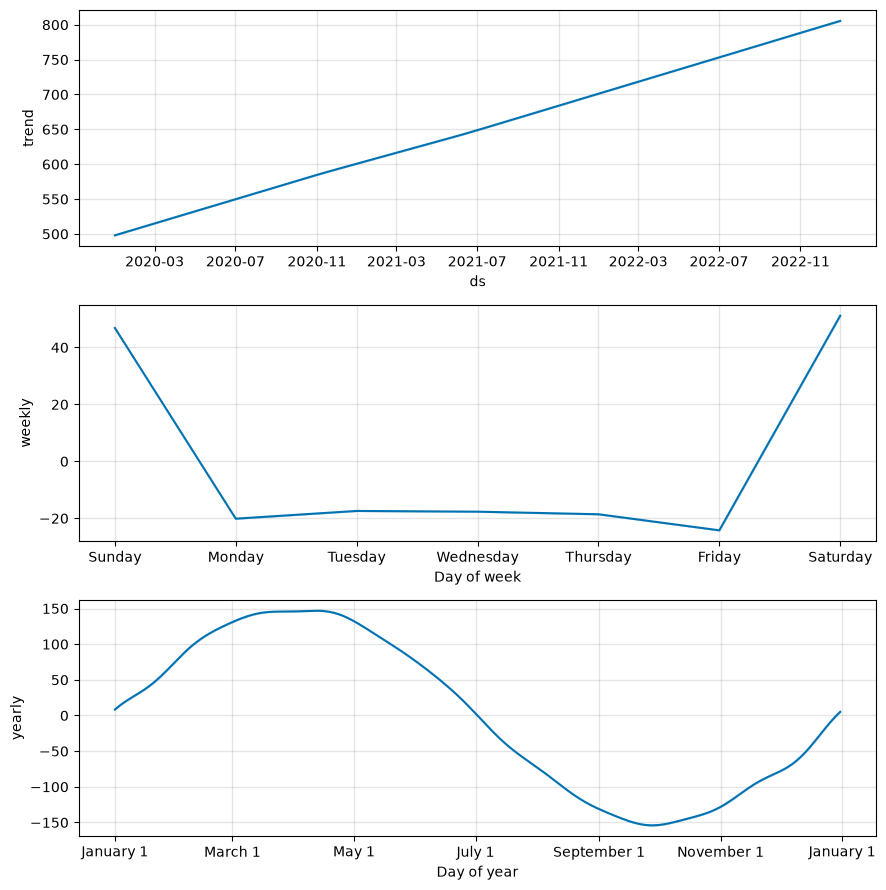

In [8]:
fig2 = model.plot_components(forecast)
plt.show()

**Comment lire ces graphiques ?**
1. **Trend (En haut)** : La tendance globale. Le modèle a bien compris que nos ventes augmentent avec les années.
2. **Weekly (Au milieu)** : Le modèle montre clairement que le Dimanche (Sunday) et le Samedi sont nos meilleurs jours.
3. **Yearly (En bas)** : Le modèle montre que nous avons un pic d'activité au milieu de l'année (Été) et en fin d'année.